# 76 - Localization vs binarization threshold

`localization` scores the centre of mass of *thresholded* blobs: `_bin(x) = x > THRESH`
(`utils/metrics.py`), `THRESH = 0.5` today. Components, centroids and the greedy GT->pred
match all inherit that one cut.

**Read figure 2 before believing figure 1.** `localization` iterates over TARGET objects and
takes the nearest unused prediction, so *extra predicted blobs cost nothing* -- `match_objects`
returns them as `extra` and the metric ignores them. Shattering a prediction into fragments
therefore drives the error DOWN while the object count becomes nonsense. On
`pm-p3-boombox-full-v1` the localization optimum sits near `1e-4`, where the count is correct
for ~2% of samples and the prediction has broken into ~15 pieces. The component count is the
independent check the localization number cannot touch, which is why figure 1 also carries a
dashed **count-conditioned** curve: the same error over only the samples that got the count
right. The gap between solid and dashed is how much the metric is being gamed.

Three things this notebook is careful about:

- **Log-spaced thresholds.** A linear `0.01 -> 0.99` sweep never samples the region where the
  gaming happens, and the curves look reassuringly monotone.
- **The target is pinned at 0.5.** `localization` binarizes pred AND truth at THRESH and the
  downsampled targets carry fractional edge cells, so a naive sweep moves the goalposts too.
  Measured, the effect is small (mean GT components 1.761 -> 1.769 across the range), but
  removing it is free.
- **`n_gt` is the labelled target, not metadata `n_objects`.** That is what the metric actually
  matches against. They agree on 99.7% of samples; the 8 that differ are two adjacent cubes
  merging into one component at 21x30, which is a real property of the grid, not an error.

`n_pred` and `n_gt` are both read off `localization(..., geometry=True)` -- `len(pairs)+len(extra)`
and `len(pairs)+len(missed)` -- so the counts come from the same pass as the numbers and cannot
drift from them.

```
RUN=pm-p3-boombox-full-v1 jupyter nbconvert --execute --inplace notebooks/76_localization_threshold.ipynb
```

In [1]:
import os, sys
from pathlib import Path

import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "src"))

import utils.metrics as M
from viz import config as C, data as D

EXP  = ROOT / "experiments/31_07_2026_gastronorm_exp1"
RUNS = ROOT / "runs"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
UNDER, EXACT, OVER = "#5b7fa6", "#2ca05a", "#e08a1e"

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
def sweep(run=None, n=100, epoch=None, exp=EXP, runs=RUNS, shape=(21, 30), lo=1e-5, hi=0.99):
  """Per-sample localization AND object count at n log-spaced thresholds.

  THRESH is a module global `_bin` reads at call time, so sweeping it is a plain rebind;
  restored in `finally`, since leaking a swept value would mis-score every later cell.
  """
  run = run or os.environ["RUN"]
  C.set_mask_shape(*shape)
  gt = D.load_gt(exp); rd = D.load_run(run, runs, gt, epoch=epoch)
  pred  = torch.from_numpy(rd.masks)
  # Pinned target: {0,1} survives any THRESH in [0,1), so only the PREDICTION cut moves.
  truth = (torch.from_numpy(gt.masks[[gt.row_of[int(s)] for s in rd.sample_ids]]) > 0.5).float()
  ts = np.geomspace(lo, hi, n)                       # log: the action is all below 0.01
  keep, N = M.THRESH, len(pred)
  loc = {k: np.empty((n, N), np.float32) for k in M.LOC_KEYS}
  npred, ngt, area = np.empty((n, N), np.int32), None, np.empty((n, N), np.float32)
  try:
    for i, t in enumerate(ts):
      M.THRESH = float(t)
      mets, geom = M.localization(pred, truth, geometry=True)
      for k in M.LOC_KEYS: loc[k][i] = mets[k].numpy()
      npred[i] = [len(g["pairs"]) + len(g["extra"]) for g in geom]
      if ngt is None:   # target is pinned, so this is threshold-invariant -- take it once
        ngt = np.array([len(g["pairs"]) + len(g["missed"]) for g in geom], np.int32)
      area[i] = M._bin(pred).numpy().reshape(N, -1).mean(1)
  finally:
    M.THRESH = keep
  return dict(ts=ts, loc=loc, npred=npred, ngt=ngt, area=area, thresh=keep,
              sp=np.array(rd.splits), names=sorted(set(rd.splits)),
              run=run, epoch=rd.epoch, shape=rd.shape)

In [3]:
def _axes(S, ax, ttl):
  ax.axvline(S["thresh"], color="#333", ls="--", lw=1.1, zorder=6)   # over the bands, not under
  ax.set_xscale("log"); ax.set_xlim(S["ts"][0], S["ts"][-1])
  ax.set_title(ttl, fontsize=9); ax.set_xlabel("THRESH"); ax.grid(alpha=.25)

def plot_localization(S, min_n=5):
  """2x3 error panels. Solid = all samples (gameable). Dashed = only samples whose object
  count is right, which is the same number with the loophole closed. Dot = min of each."""
  ok = S["npred"] == S["ngt"][None, :]
  f, axes = plt.subplots(2, 3, figsize=(15, 7.5))
  for a, k in zip(axes.ravel(), M.LOC_KEYS):
    v = S["loc"][k]
    for s in S["names"]:
      m = S["sp"] == s
      allv = np.nanmean(np.where(np.isnan(v[:, m]), np.nan, v[:, m]), axis=1)
      sel = ok[:, m] & ~np.isnan(v[:, m])
      cnt = sel.sum(1)
      condv = np.full(len(S["ts"]), np.nan)
      i2 = np.where(cnt >= min_n)[0]          # skip all-NaN rows rather than warn on them
      if len(i2): condv[i2] = np.nanmean(np.where(sel[i2], v[:, m][i2], np.nan), axis=1)
      (ln,) = a.plot(S["ts"], allv, lw=1.4, label=s)
      a.plot(S["ts"], condv, lw=1.2, ls=":", color=ln.get_color(), alpha=.9)
      i = int(np.nanargmin(allv)); a.plot(S["ts"][i], allv[i], "o", ms=5,
                                          mfc=ln.get_color(), mec="white", mew=1, zorder=5)
    _axes(S, a, k)
  axes[0, 0].set_ylabel("fraction of box"); axes[1, 0].set_ylabel("grid cells")
  axes[0, 0].legend(fontsize=6.5, ncol=2)
  f.suptitle(f'{S["run"]} ep{S["epoch"]} {S["shape"][0]}x{S["shape"][1]} -- localization vs THRESH. '
             f'solid = all samples, dotted = count-correct only, dot = min of solid, '
             f'dashed line = shipping {S["thresh"]}', fontsize=9.5)
  f.tight_layout(); return f

def plot_counts(S):
  """One panel per split: what fraction of samples over-count, get it exactly right, or
  under-count, at each threshold. Bands stack to 1, ordered so the y axis reads like the
  SIGNED error -- fragmentation up, erasure down, correct in the middle. The green plateau
  is the answer: where it sits is the usable threshold, how wide it is says how touchy that
  choice is."""
  ns = S["names"]; rows = int(np.ceil((len(ns) + 1) / 4))
  f, axes = plt.subplots(rows, 4, figsize=(16, 3.4 * rows))
  A = axes.ravel()
  for a, s in zip(A, ns):
    m = S["sp"] == s
    d = S["npred"][:, m] - S["ngt"][None, m]
    under, exact, over = (d < 0).mean(1), (d == 0).mean(1), (d > 0).mean(1)
    a.stackplot(S["ts"], under, exact, over, colors=[UNDER, EXACT, OVER], edgecolor="none")
    i = int(np.argmax(exact))
    a.axvline(S["ts"][i], color="#111", lw=1.2)
    a.plot(S["ts"][i], exact[i], "o", ms=6, mfc=EXACT, mec="#111", mew=1.2, zorder=6, clip_on=False)
    gts = np.bincount(S["ngt"][m]); 
    _axes(S, a, f"{s}  (n={int(m.sum())}, n_gt={np.argmax(gts)})   best {S['ts'][i]:.4f} -> {exact[i]:.0%}")
    a.set_ylim(0, 1); a.set_ylabel("fraction of samples")
  a = A[len(ns)]
  a.axis("off")
  a.legend(handles=[plt.Rectangle((0,0),1,1,fc=c) for c in (OVER, EXACT, UNDER)],
           labels=["over-count  (n_pred > n_gt) — fragmentation",
                   "exact  (n_pred == n_gt)",
                   "under-count  (n_pred < n_gt) — erased"], loc="center", fontsize=9, frameon=False)
  for a in A[len(ns) + 1:]: a.axis("off")
  f.suptitle("Object count vs threshold — the check localization cannot game "
             "(black line + dot = widest agreement; dashed = shipping 0.5)", fontsize=10)
  f.tight_layout(); return f

def plot_count_hist(S, splits=("2-cubes", "3-cubes"), top=8):
  """What the WRONG counts actually are. The bands say "wrong"; this says off-by-one or
  off-by-fifteen, which is the difference between a threshold nudge and a broken run."""
  f, axes = plt.subplots(1, len(splits), figsize=(7.4 * len(splits), 3.8))
  for a, s in zip(np.atleast_1d(axes), splits):
    m = S["sp"] == s
    if not m.sum(): a.axis("off"); continue
    npc = np.clip(S["npred"][:, m], 0, top)
    Z = np.stack([np.bincount(r, minlength=top + 1) for r in npc]).T / m.sum()
    im = a.pcolormesh(S["ts"], np.arange(top + 1), np.where(Z > 0, Z, np.nan),
                      shading="nearest", cmap="magma_r", norm=LogNorm(vmin=1e-3, vmax=1))
    a.axhline(np.bincount(S["ngt"][m]).argmax(), color="#00c2ff", lw=1.6, ls="-")
    _axes(S, a, f"{s}  (n={int(m.sum())})  — blue line = n_gt")
    a.set_ylabel("predicted components"); a.set_yticks(range(top + 1))
    a.set_yticklabels([str(i) for i in range(top)] + [f"{top}+"])
    f.colorbar(im, ax=a, fraction=.046, label="fraction of samples")
  f.suptitle("Distribution of predicted object count", fontsize=10)
  f.tight_layout(); return f

def report(S):
  ok = S["npred"] == S["ngt"][None, :]
  v = S["loc"]["localization_rel"]
  print(f"{'split':<22}{'loc-best':>10}{'loc':>8}{'match':>8}   |{'count-best':>11}{'match':>7}{'loc':>8}"
        f"   |{'@0.5 loc':>10}{'match':>7}")
  for s in S["names"]:
    m = S["sp"] == s
    allv = np.nanmean(v[:, m], axis=1); ex = ok[:, m].mean(1)
    i, j = int(np.nanargmin(allv)), int(np.argmax(ex))
    h = int(np.argmin(abs(S["ts"] - S["thresh"])))
    print(f"{s:<22}{S['ts'][i]:>10.5f}{allv[i]:>8.4f}{ex[i]:>7.1%}   |"
          f"{S['ts'][j]:>11.5f}{ex[j]:>6.1%}{allv[j]:>8.4f}   |{allv[h]:>10.4f}{ex[h]:>6.1%}")

def run_all(run=None, **kw):
  S = sweep(run, **kw); report(S)
  return S, (plot_localization(S), plot_counts(S), plot_count_hist(S))

split                   loc-best     loc   match   | count-best  match     loc   |  @0.5 loc  match
1-cube                   0.00011  0.0411   8.0%   |    0.01197 88.4%  0.0619   |    0.4463 69.6%
1-cube-speaker           0.04297  0.0221  98.4%   |    0.01345 98.4%  0.0233   |    0.0864 95.2%
2-cubes                  0.00009  0.0715   0.0%   |    0.00596 81.2%  0.1573   |    0.5941 39.6%
2-cubes-speaker          0.00235  0.0182  96.4%   |    0.00949100.0%  0.0209   |    0.1075 89.1%
3-cubes                  0.00007  0.1268   0.0%   |    0.00016 47.5%  0.2830   |    0.9757  0.0%
red-cube                 0.12228  0.0246  55.0%   |    0.62200 85.0%  0.0970   |    0.0659 80.0%
train                    0.49303  0.0010 100.0%   |    0.43894100.0%  0.0048   |    0.0010100.0%


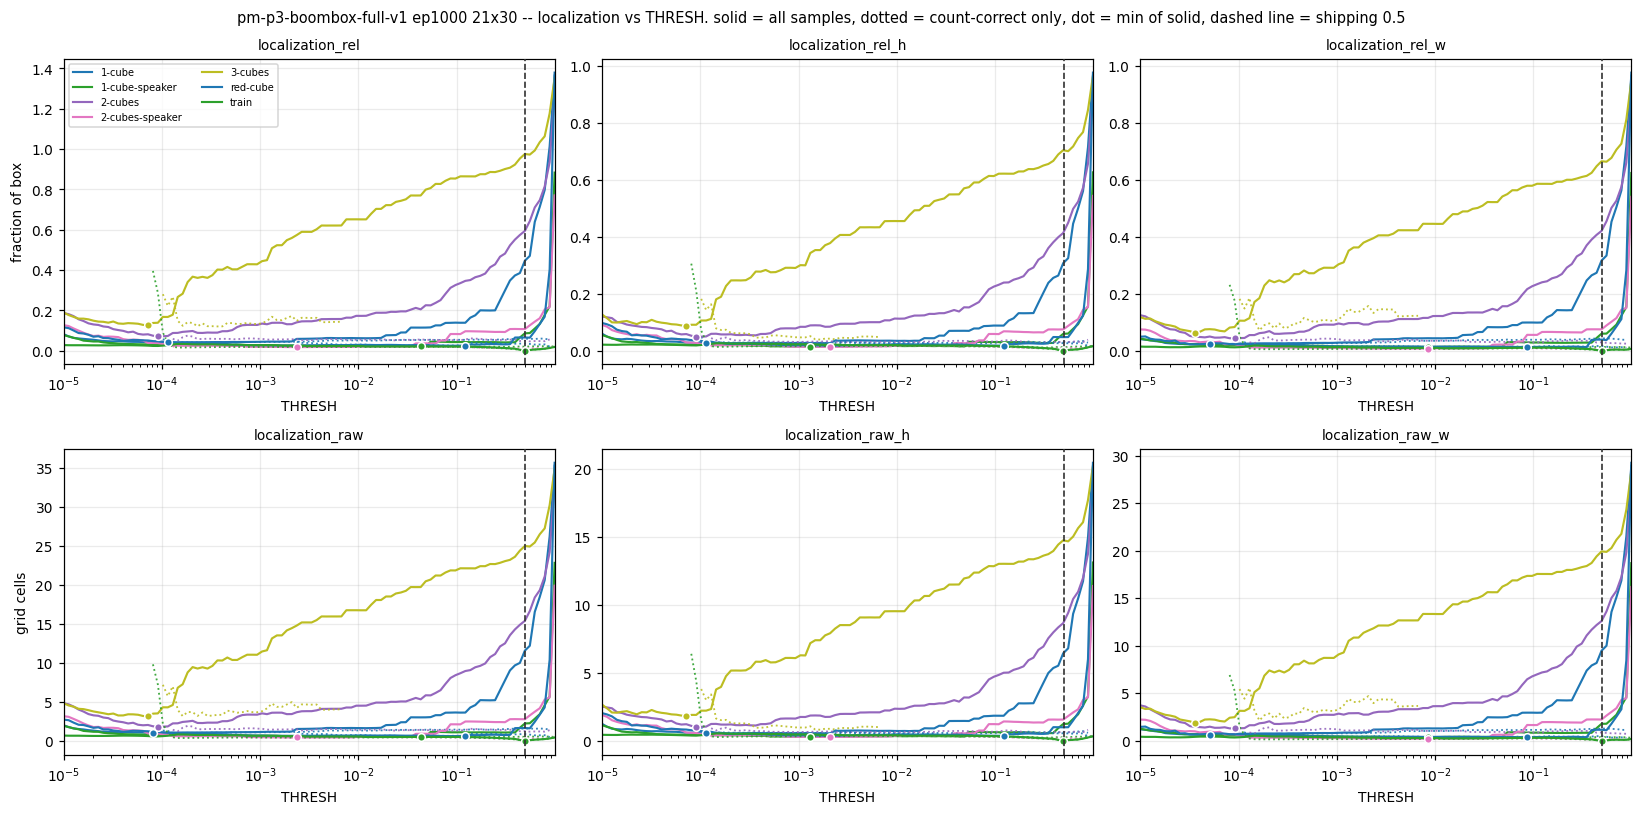

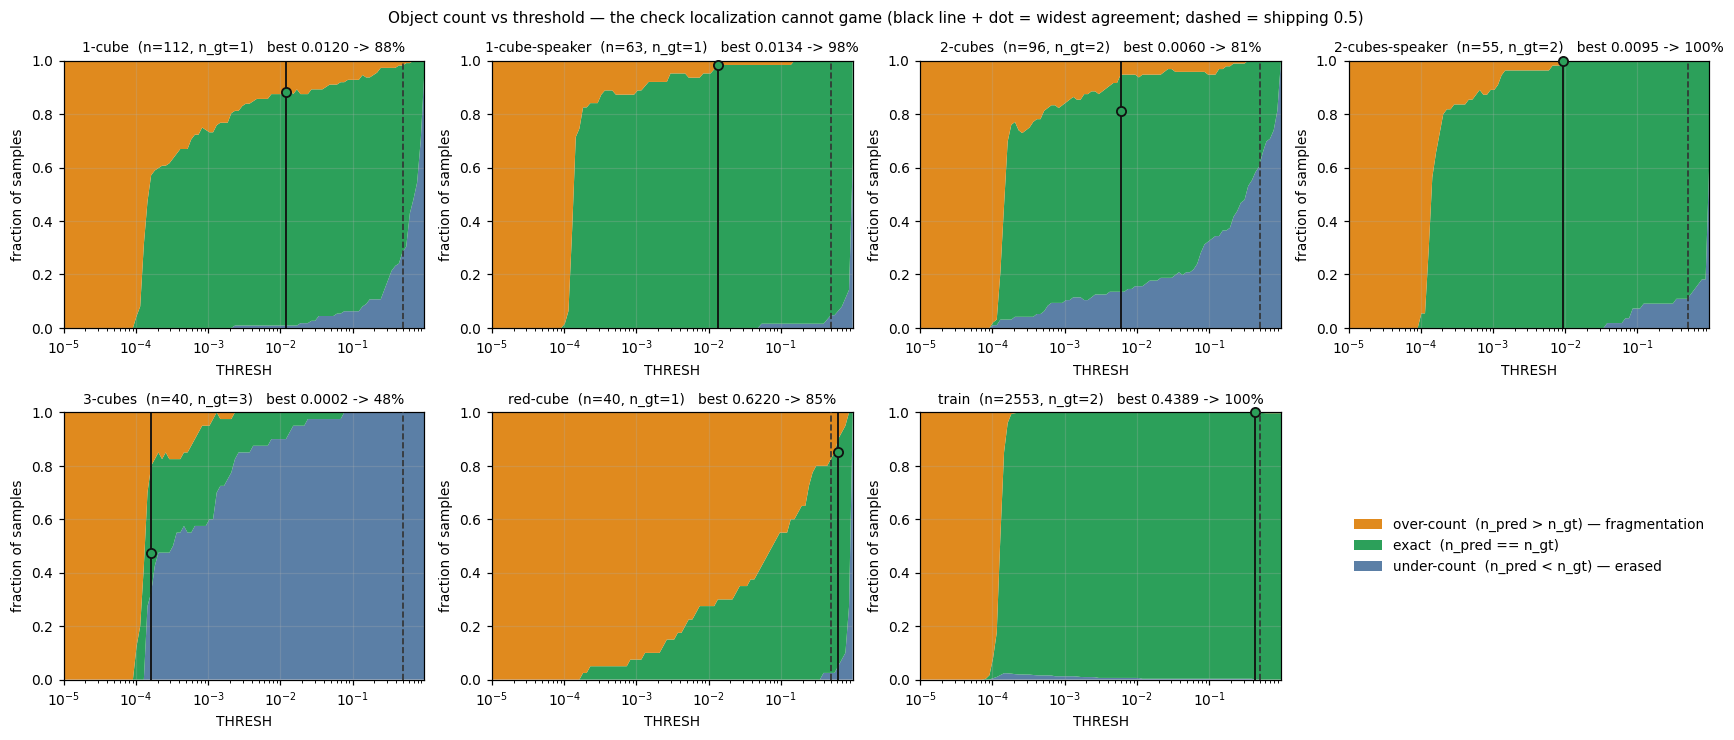

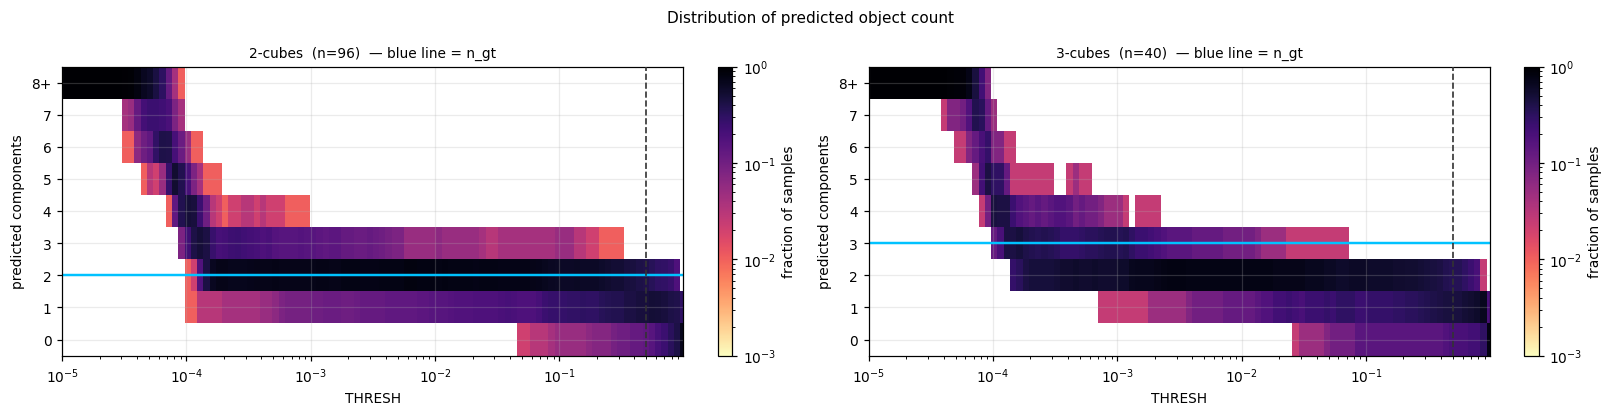

In [4]:
S, figs = run_all()
plt.show()

---

## Does a per-sample normalization fix the count?

The failure above is not that 0.5 is too high, it is that **no single threshold works**: the
count-optimal cut ranges from 0.006 (`2-cubes`) to 0.62 (`red-cube`), a 100x spread, because each
sample's prediction sits at its own confidence scale. That is exactly what a per-sample
normalization is supposed to remove, so the test is not "does the best rate improve" -- it is
**does the spread collapse**, i.e. does one shared threshold now work everywhere.

Four candidates, all applied per sample:

| | what | threshold axis |
|---|---|---|
| `raw p` | nothing, the baseline | absolute |
| `p / max` | divide by the peak cell | fraction of peak |
| `p / sum` | divide by total mass | multiples of uniform (1/N) |
| `softmax(logit p)` | the proposed one | multiples of uniform (1/N) |

A note on the last: `mask_pred` is already **sigmoid probabilities**, so a softmax straight over
those is nearly flat (the largest possible ratio is `e/1 = 2.7`) and would destroy the signal. It
has to go through logits first -- and `softmax(logit p)` is then exactly the normalized **odds**,
`(p/(1-p)) / sum_j (p_j/(1-p_j))`. That is a much sharper transform than `p/sum`: odds diverge as
`p -> 1`, so a handful of confident cells can take nearly all the mass. Predictions are stored
fp16 and saturate at exactly 0 and 1, so `p` is clamped before the division.

`p/sum` and `softmax` are rescaled by `N = h*w` so that **1.0 on their axis means "uniform"** and
the three axes are readable side by side.

In [5]:
def compare_norms(run=None, n=60, epoch=None, exp=EXP, runs=RUNS, shape=(21, 30), skip=("train",)):
  """exact / over / under object counts vs threshold, for several per-sample normalizations.

  Counts only -- no localization -- so this needs one labelling per threshold rather than a
  full scoring pass. THRESH is never touched: the cut is applied directly, so nothing here
  can leak into the module global the rest of the notebook sweeps.
  """
  run = run or os.environ["RUN"]
  C.set_mask_shape(*shape)
  gt = D.load_gt(exp); rd = D.load_run(run, runs, gt, epoch=epoch)
  p = torch.from_numpy(rd.masks).float()
  truth = (torch.from_numpy(gt.masks[[gt.row_of[int(s)] for s in rd.sample_ids]]) > 0.5).float()
  sp = np.array(rd.splits); names = [s for s in sorted(set(rd.splits)) if s not in skip]
  N = shape[0] * shape[1]
  ncomp = lambda x, t: np.array([len(c) for c in M._centroids_batch(M._label((x > t).float()).cpu())])
  ngt = ncomp(truth, 0.5)
  amax = lambda x: x.amax(dim=(-2, -1), keepdim=True).clamp_min(1e-9)
  asum = lambda x: x.sum(dim=(-2, -1), keepdim=True).clamp_min(1e-9)
  q = p.clamp(1e-6, 1 - 1e-6); odds = q / (1 - q)      # softmax over logits == normalized odds
  meth = {
    "raw p":            (p,                     np.geomspace(1e-5, .99, n), "THRESH (absolute)"),
    "p / max":          (p / amax(p),           np.geomspace(1e-3, .99, n), "fraction of peak"),
    "p / sum":          (p / asum(p) * N,       np.geomspace(1e-2, 1e3, n), "multiples of uniform"),
    "softmax(logit p)": (odds / asum(odds) * N, np.geomspace(1e-2, 1e3, n), "multiples of uniform"),
  }
  R = {}
  for name, (x, ts, xlab) in meth.items():
    nc = np.stack([ncomp(x, float(t)) for t in ts])            # (T, N)
    d = nc - ngt[None, :]
    R[name] = dict(ts=ts, xlab=xlab,
                   band={s: {k: f(d[:, sp == s]) for k, f in
                             (("under", lambda z: (z < 0).mean(1)), ("exact", lambda z: (z == 0).mean(1)),
                              ("over",  lambda z: (z > 0).mean(1)))} for s in names},
                   held=np.concatenate([d[:, sp == s] for s in names], axis=1))
  return R, names


def plot_norms(R, names):
  """Row 1: exact-count rate per split, so the question "do the optima collapse onto one
  threshold" is answered by whether the dots line up. Row 2: the same bands as before, over
  every held-out sample pooled, so the shape of the failure is visible per method."""
  f, ax = plt.subplots(2, len(R), figsize=(4.3 * len(R), 7.2))
  for j, (name, r) in enumerate(R.items()):
    a = ax[0, j]
    for s in names:
      (ln,) = a.plot(r["ts"], r["band"][s]["exact"], lw=1.4, label=s)
      i = int(np.argmax(r["band"][s]["exact"]))
      a.plot(r["ts"][i], r["band"][s]["exact"][i], "o", ms=5, mfc=ln.get_color(), mec="white", mew=1, zorder=5)
    a.set_xscale("log"); a.set_ylim(0, 1); a.grid(alpha=.25)
    a.set_title(name, fontsize=10); a.set_xlabel(r["xlab"])
    # best SINGLE threshold shared by every held-out split -- the number that matters
    mean = np.mean([r["band"][s]["exact"] for s in names], axis=0)
    k = int(np.argmax(mean))
    a.axvline(r["ts"][k], color="#111", lw=1.2)
    a.set_xlabel(f'{r["xlab"]}\nbest shared {r["ts"][k]:.3g} -> mean {mean[k]:.0%}, worst '
                 f'{min(r["band"][s]["exact"][k] for s in names):.0%}', fontsize=8)
    d = r["held"]
    b = ax[1, j]
    b.stackplot(r["ts"], (d < 0).mean(1), (d == 0).mean(1), (d > 0).mean(1),
                colors=[UNDER, EXACT, OVER], edgecolor="none")
    b.axvline(r["ts"][k], color="#111", lw=1.2, zorder=6)
    b.set_xscale("log"); b.set_ylim(0, 1); b.set_xlim(r["ts"][0], r["ts"][-1])
    b.grid(alpha=.25); b.set_xlabel(r["xlab"])
  ax[0, 0].set_ylabel("P(n_pred == n_gt), per split"); ax[1, 0].set_ylabel("all held-out samples pooled")
  ax[0, 0].legend(fontsize=6.5, ncol=2)
  ax[1, -1].legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=c) for c in (OVER, EXACT, UNDER)],
                   labels=["over", "exact", "under"], fontsize=7, loc="lower left", framealpha=.85)
  f.suptitle("Does a per-sample normalization make ONE threshold work? "
             "(dot = per-split best, black line = best shared)", fontsize=10)
  f.tight_layout(); return f


def report_norms(R, names):
  print(f"{'method':<20}{'spread':>9}   " + "".join(f"{s[:13]:>15}" for s in names))
  for name, r in R.items():
    best = [r["ts"][int(np.argmax(r["band"][s]["exact"]))] for s in names]
    print(f"{name:<20}{max(best)/min(best):>8.0f}x   " + "".join(f"{b:>15.4g}" for b in best))
  print("\n  per-split optimal thresholds above; 'spread' = max/min. "
        "A normalization that works drives spread toward 1.\n")
  print(f"{'method':<20}{'shared t':>10}{'mean':>7}{'worst':>7}   " + "".join(f"{s[:13]:>15}" for s in names))
  for name, r in R.items():
    mean = np.mean([r["band"][s]["exact"] for s in names], axis=0)
    k = int(np.argmax(mean))
    v = [r["band"][s]["exact"][k] for s in names]
    print(f"{name:<20}{r['ts'][k]:>10.4g}{mean[k]:>7.0%}{min(v):>7.0%}   " + "".join(f"{x:>15.0%}" for x in v))

method                 spread            1-cube  1-cube-speake        2-cubes  2-cubes-speak        3-cubes       red-cube
raw p                   4374x           0.01117        0.01358       0.006225       0.009194      0.0001533         0.6703
p / max                  990x            0.8808         0.1525       0.004067        0.01036          0.001           0.99
p / sum                 4406x             96.17          20.19         0.4075          1.597        0.02183          96.17
softmax(logit p)       11690x             96.17          2.868         0.1867        0.03225           0.01          116.9

  per-split optimal thresholds above; 'spread' = max/min. A normalization that works drives spread toward 1.

method                shared t   mean  worst            1-cube  1-cube-speake        2-cubes  2-cubes-speak        3-cubes       red-cube
raw p                  0.05316    67%     2%               87%            97%            75%            98%             2%            42

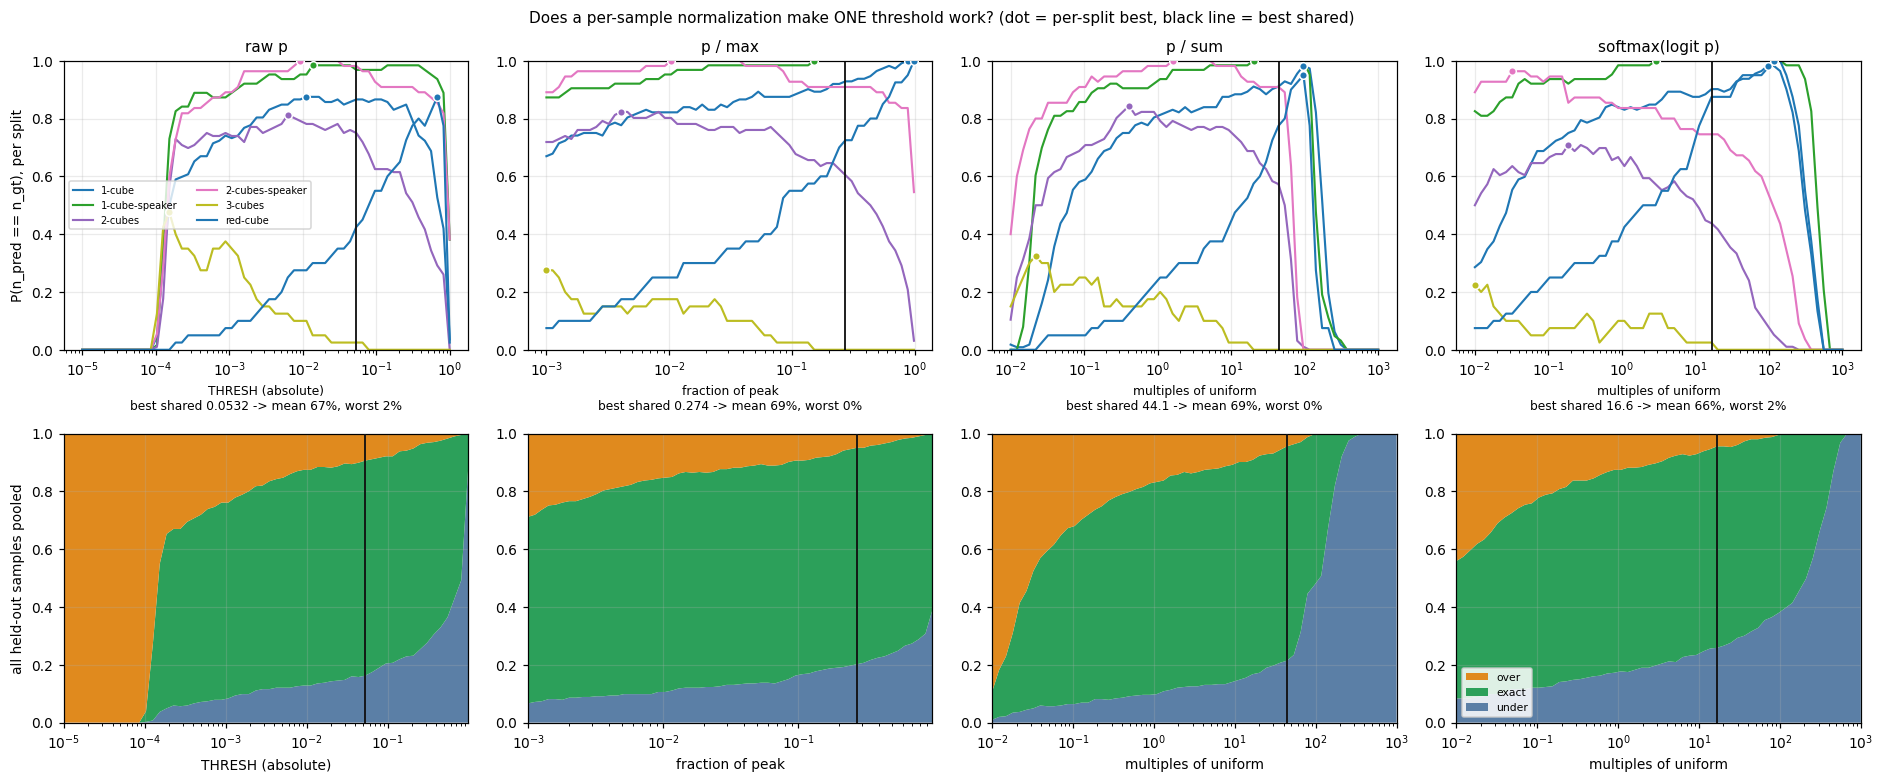

In [6]:
R, hnames = compare_norms()
report_norms(R, hnames)
fn = plot_norms(R, hnames)
plt.show()